In [1]:
import os

# Suppress gRPC C++ logs (the E0000 lines)
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['GLOG_minloglevel'] = '2'

import pandas as pd
pd.options.future.infer_string = False
import pypsa

E0000 00:00:1773607897.099805 40670266 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773607897.100809 40670266 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1773607897.100815 40670266 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773607897.100817 40670266 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1773607897.100819 40670266 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [2]:
network = pypsa.Network()
hours_in_2017 = pd.date_range('2017-01-01 00:00:00',
                              '2017-12-31 23:00:00',
                              freq='h')

network.set_snapshots(hours_in_2017)
network.add("Bus",
            "electricity bus")

network.snapshots


DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2017-12-31 14:00:00', '2017-12-31 15:00:00',
               '2017-12-31 16:00:00', '2017-12-31 17:00:00',
               '2017-12-31 18:00:00', '2017-12-31 19:00:00',
               '2017-12-31 20:00:00', '2017-12-31 21:00:00',
               '2017-12-31 22:00:00', '2017-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq='h')

In [3]:
# load electricity demand data
df_elec = pd.read_csv('data/load_2017_SwedanZone4.csv', sep=',', index_col=0) # in MW
df_elec.index = df_elec.index.str.split(' - ').str[0] # to separate the range of dates
df_elec.index = pd.to_datetime(df_elec.index, dayfirst=True, errors='coerce') # to convert the index to datetime
df_elec = df_elec[['Actual Total Load (MW)']] # to select the column with the electricity demand data

print(df_elec.head())

                     Actual Total Load (MW)
MTU (CET/CEST)                             
2017-01-01 00:00:00                  2388.0
2017-01-01 01:00:00                  2342.0
2017-01-01 02:00:00                  2291.0
2017-01-01 03:00:00                  2189.0
2017-01-01 04:00:00                  2155.0


In [4]:
#network.set_snapshots(df_elec.index)
#network.snapshots

In [5]:
# add load to the bus

network.add("Load",
            "load",
            bus="electricity bus",
            p_set=df_elec["Actual Total Load (MW)"].values)

In [6]:
network.loads_t.p_set

name,load
snapshot,
2017-01-01 00:00:00,2388.0
2017-01-01 01:00:00,2342.0
2017-01-01 02:00:00,2291.0
2017-01-01 03:00:00,2189.0
2017-01-01 04:00:00,2155.0
...,...
2017-12-31 19:00:00,3148.0
2017-12-31 20:00:00,2891.0
2017-12-31 21:00:00,2758.0


In [7]:
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n

In [8]:
# We add the different carries: nuclear, gas, solar and wind

network.add("Carrier", "onshorewind")
network.add("Carrier", "offshorewind")
network.add("Carrier", "solar")
network.add("Carrier", "nuclear")
network.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
country = 'SWE'

# add onshore wind generator
df_onshorewind = pd.read_csv('data/CF_onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)
CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_onshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "onshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values)

# add offshore wind generator
df_offshorewind = pd.read_csv('data/CF_offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)
CF_wind = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_offshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "offshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values)


# add solar PV generator
df_solar = pd.read_csv('data/CF_pv_optimal.csv', sep=';', index_col=0)
df_solar.index = pd.to_datetime(df_solar.index)
CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_solar = annuity(25,0.07)*425000*(1+0.03) # in €/MW
network.add("Generator",
            "solar",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="solar",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_solar,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)


# add nuclear generator
life_nuclear = 60                    # years
cap_nuclear = 6000000               # €/MW_el
fom_nuclear = 0.025                 # 2.5%/year
capital_cost_nuclear = annuity(life_nuclear, 0.07) * cap_nuclear * (1 + fom_nuclear)

marginal_cost_nuclear = 10.0        # €/MWh_el (example stylized value)

network.add("Generator",
            "nuclear",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="nuclear",
            capital_cost=capital_cost_nuclear,
            marginal_cost=marginal_cost_nuclear)


# add OCGT (Open Cycle Gas Turbine) generator
capital_cost_OCGT = annuity(25,0.07)*560000*(1+0.033) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            marginal_cost = marginal_cost_OCGT)


In [9]:
network.generators_t.p_max_pu

name,onshorewind,offshorewind,solar
snapshot,,,
2017-01-01 00:00:00,0.325,0.678,0.0
2017-01-01 01:00:00,0.314,0.697,0.0
2017-01-01 02:00:00,0.319,0.703,0.0
2017-01-01 03:00:00,0.299,0.696,0.0
2017-01-01 04:00:00,0.275,0.686,0.0
...,...,...,...
2017-12-31 19:00:00,0.217,0.525,0.0
2017-12-31 20:00:00,0.196,0.496,0.0
2017-12-31 21:00:00,0.182,0.410,0.0


In [10]:
network.optimize(solver_name='gurobi')

/var/folders/k2/mns8khpd5j76cc436d914hvw0000gn/T/ipykernel_12672/3854944838.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 308.97it/s]
INFO:linopy.io: Writing time: 0.26s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2790071


INFO:gurobipy:Set parameter LicenseID to value 2790071


...

Solved in 14300 iterations and 1.23 seconds (0.80 work units)


INFO:gurobipy:Solved in 14300 iterations and 1.23 seconds (0.80 work units)


Optimal objective  1.110701586e+09


INFO:gurobipy:Optimal objective  1.110701586e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96365 duals
Objective: 1.11e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [11]:
print(network.objective/1000000) #in 10^6 €

1110.7015860848114


In [12]:
print(network.objective/network.loads_t.p.sum()) # EUR/MWh

name
load    45.501588
dtype: float64


In [13]:
network.generators.p_nom_opt # in MW

name
onshorewind        0.000000
offshorewind    6155.555556
solar              0.000000
nuclear            0.000000
OCGT            4307.666667
Name: p_nom_opt, dtype: float64

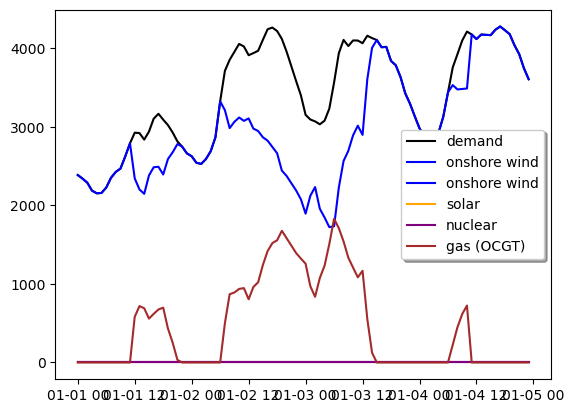

In [14]:
import matplotlib.pyplot as plt

plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['offshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
plt.legend(fancybox=True, shadow=True, loc='best')

Text(0.5, 1.07, 'Electricity mix')

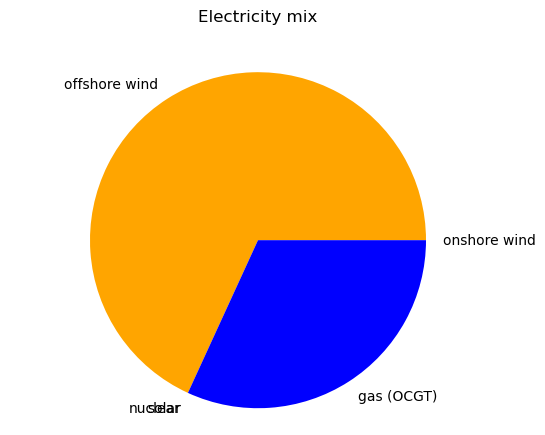

In [15]:
labels = ['onshore wind',
          'offshore wind',
          'solar',
          'nuclear',    
          'gas (OCGT)']
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors=['blue', 'orange', 'brown', 'green'] 

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

In [16]:
co2_limit=1000000 #tonCO2
network.add("GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_limit)
network.optimize(solver_name='gurobi')

/var/folders/k2/mns8khpd5j76cc436d914hvw0000gn/T/ipykernel_12672/2428468447.py:8: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electricity bus'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 399.04it/s]
INFO:linopy.io: Writing time: 0.07s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2790071


INFO:gurobipy:Set parameter LicenseID to value 2790071


...

Solved in 10622 iterations and 1.47 seconds (0.85 work units)


INFO:gurobipy:Solved in 10622 iterations and 1.47 seconds (0.85 work units)


Optimal objective  1.160652620e+09


INFO:gurobipy:Optimal objective  1.160652620e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96366 duals
Objective: 1.16e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


ValueError: setting an array element with a sequence.

In [17]:
network.generators.p_nom_opt #in MW

name
onshorewind        0.000000
offshorewind    7730.639731
solar           2015.010164
nuclear            0.000000
OCGT            4186.966484
Name: p_nom_opt, dtype: float64

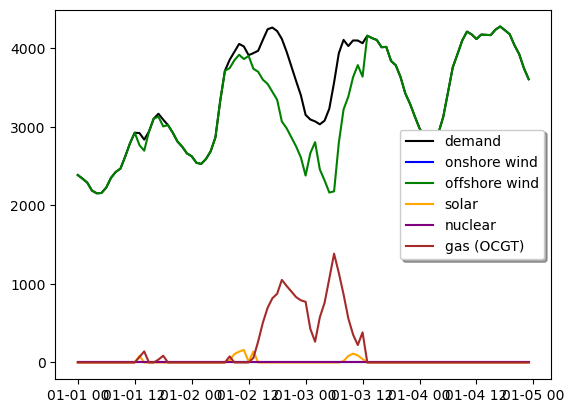

In [18]:
plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['offshorewind'][0:96], color='green', label='offshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
plt.legend(fancybox=True, shadow=True, loc='best')

Text(0.5, 1.07, 'Electricity mix')

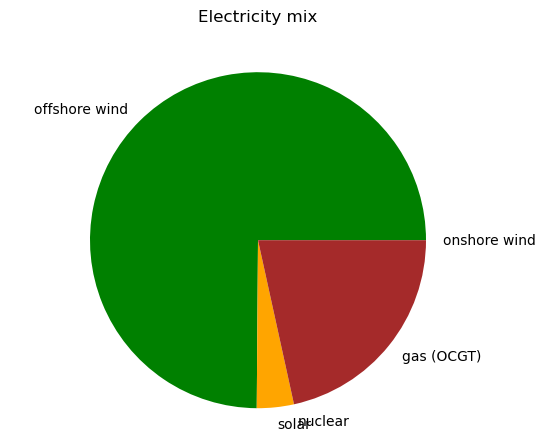

In [19]:
labels = ['onshore wind', 'offshore wind', 'solar', 'nuclear', 'gas (OCGT)' ]
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors = ['blue', 'green', 'orange', 'purple', 'brown']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

## Part A

hoose a different country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the cost assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.

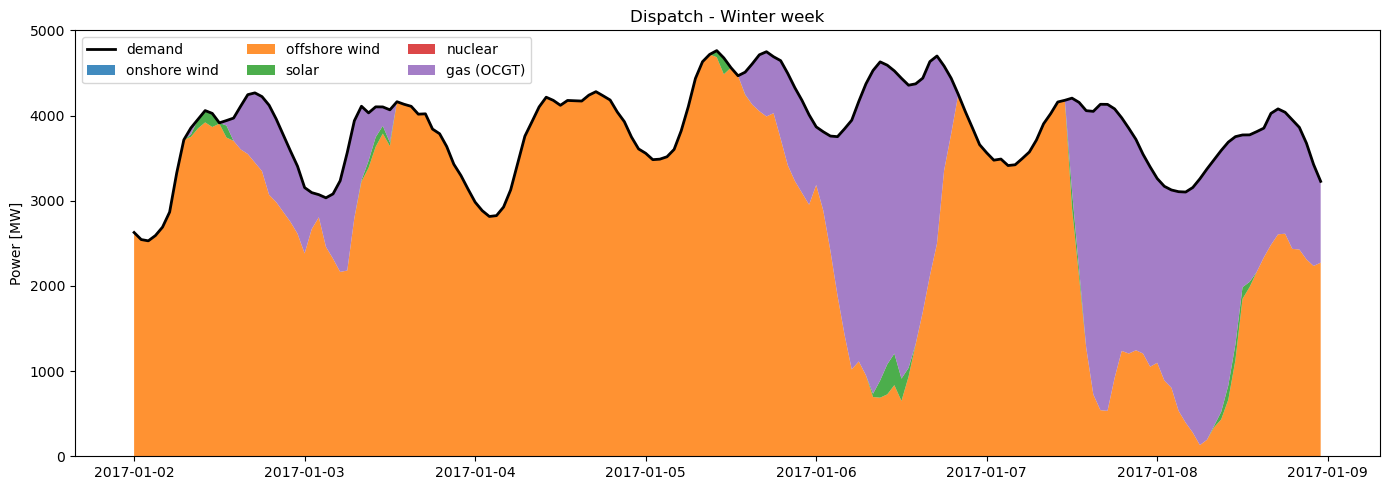

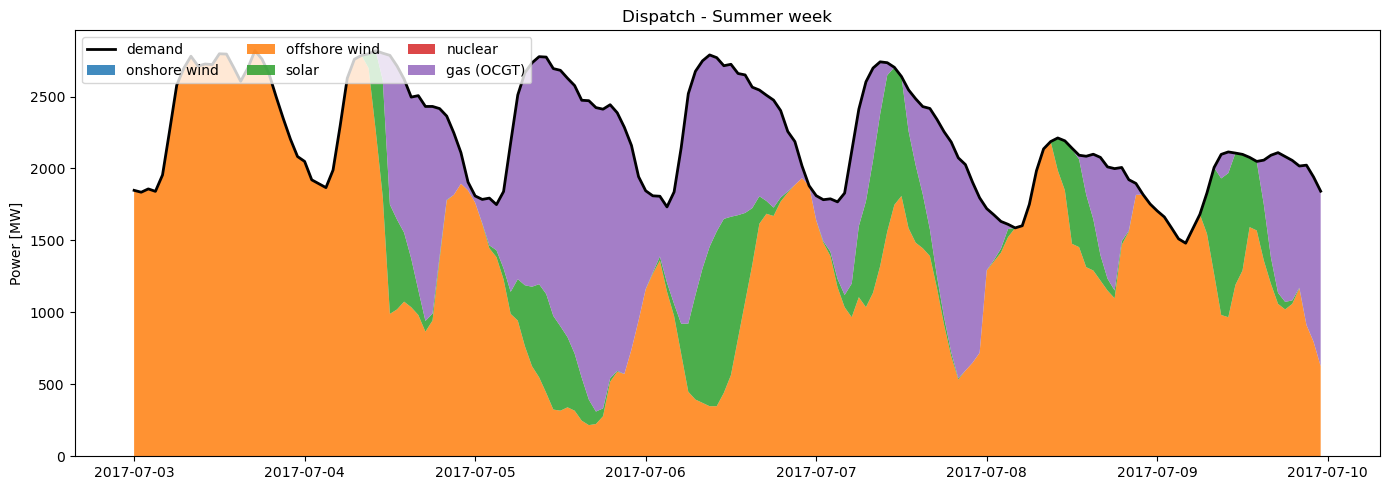

In [20]:
# Winter week and summer week 
import matplotlib.pyplot as plt

def plot_dispatch_week(network, start_date, end_date, title):
    dispatch = network.generators_t.p.loc[start_date:end_date, ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]]
    demand = network.loads_t.p.loc[start_date:end_date, "load"]

    plt.figure(figsize=(14, 5))
    plt.plot(demand.index, demand, color="black", linewidth=2, label="demand")
    plt.stackplot(dispatch.index,
                  dispatch["onshorewind"],
                  dispatch["offshorewind"],
                  dispatch["solar"],
                  dispatch["nuclear"],
                  dispatch["OCGT"],
                  labels=["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"],
                  alpha=0.85)
    plt.title(title)
    plt.ylabel("Power [MW]")
    plt.legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()

plot_dispatch_week(network,
                   "2017-01-02 00:00:00",
                   "2017-01-08 23:00:00",
                   "Dispatch - Winter week")

plot_dispatch_week(network,
                   "2017-07-03 00:00:00",
                   "2017-07-09 23:00:00",
                   "Dispatch - Summer week")

Annual generation by technology (MWh):
name
offshorewind    18278643.0
OCGT             5263158.0
solar             868371.0
onshorewind            0.0
nuclear                0.0
dtype: float64


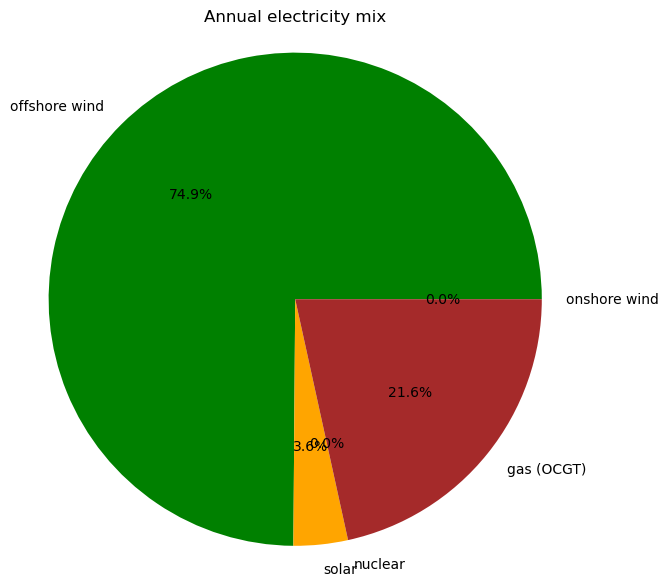

In [21]:
# Annual generation
annual_generation = network.generators_t.p.sum().sort_values(ascending=False)
print("Annual generation by technology (MWh):")
print(annual_generation.round(0))

labels = ["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"]
sizes = [
    network.generators_t.p["onshorewind"].sum(),
    network.generators_t.p["offshorewind"].sum(),
    network.generators_t.p["solar"].sum(),
    network.generators_t.p["nuclear"].sum(),
    network.generators_t.p["OCGT"].sum()
]

colors = ["blue", "green", "orange", "purple", "brown"]

plt.figure(figsize=(7, 7))
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        wedgeprops={"linewidth": 0})
plt.axis("equal")
plt.title("Annual electricity mix")
plt.show()

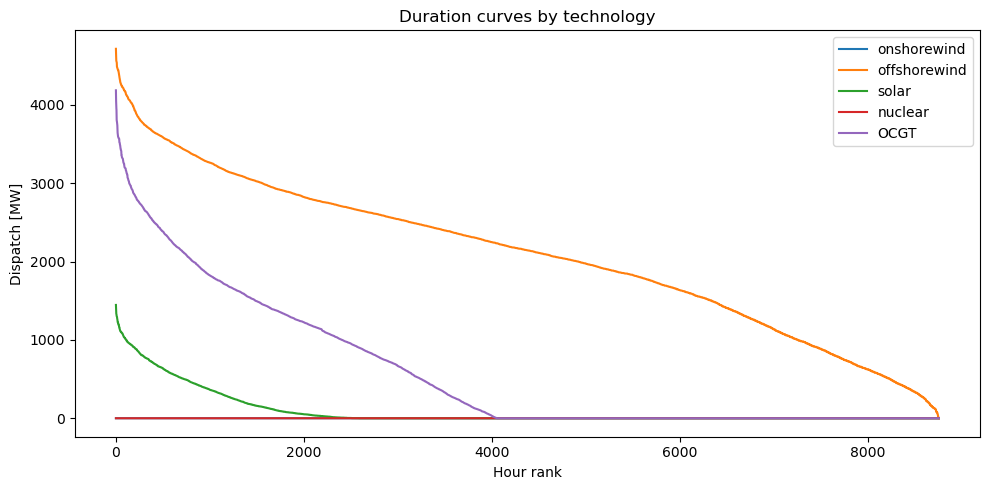

In [22]:
# Duration curves

# %%
plt.figure(figsize=(10, 5))

for tech in ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]:
    sorted_dispatch = network.generators_t.p[tech].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=tech)

plt.xlabel("Hour rank")
plt.ylabel("Dispatch [MW]")
plt.title("Duration curves by technology")
plt.legend()
plt.tight_layout()
plt.show()

## Part B

Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.

In [ ]:
weather_years = range(2000, 2018)   # only adding 18 years cause if not it's too slow :(
results = []

# keep 2017 demand for all runs to isolate weather sensitivity
load_2017 = df_elec["Actual Total Load (MW)"].values

for year in weather_years:
    print(f"Running weather year {year}...")

    # 1. Create snapshots for this weather year
    new_snapshots = pd.date_range(f"{year}-01-01 00:00", f"{year}-12-31 23:00", freq="h")
    network.set_snapshots(new_snapshots)

    # 2. Extract renewable profiles for this exact year
    onshore_year = df_onshorewind[country][df_onshorewind.index.year == year]
    offshore_year = df_offshorewind[country][df_offshorewind.index.year == year]
    solar_year = df_solar[country][df_solar.index.year == year]

    # 3. Make sure lengths match
    if not (len(onshore_year) == len(new_snapshots) == len(offshore_year) == len(solar_year)):
        print(f"Skipping {year}: mismatch in time series length")
        continue

    # 4. Update renewable availability
    network.generators_t.p_max_pu.loc[:, "onshorewind"] = onshore_year.values
    network.generators_t.p_max_pu.loc[:, "offshorewind"] = offshore_year.values
    network.generators_t.p_max_pu.loc[:, "solar"] = solar_year.values

    # 5. Update load
    if len(load_2017) == len(new_snapshots):
        network.loads_t.p_set.loc[:, "load"] = load_2017
    else:
        print(f"Skipping {year}: load length mismatch")
        continue

    # 6. Optimize
    network.optimize(solver_name="gurobi")

    # 7. Store capacities
    opt_caps = network.generators.p_nom_opt.copy()
    opt_caps["year"] = year
    results.append(opt_caps)

# 8. Collect all results
df_sensitivity = pd.DataFrame(results).set_index("year")

print(df_sensitivity)

/var/folders/k2/mns8khpd5j76cc436d914hvw0000gn/T/ipykernel_12672/890733085.py:37: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="gurobi")
Index(['electricity bus'], dtype='object', name='name')


Running weather year 1979...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 158.10it/s]
INFO:linopy.io: Writing time: 0.31s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:  27   1.09351659e+09  1.09170636e+09  7.59e+00 1.54e-09  1.52e+01     2s


  28   1.09298604e+09  1.09182844e+09  4.85e+00 2.91e-10  9.72e+00     2s


INFO:gurobipy:  28   1.09298604e+09  1.09182844e+09  4.85e+00 2.91e-10  9.72e+00     2s


  29   1.09253700e+09  1.09195248e+09  2.54e+00 4.07e-10  4.91e+00     2s


INFO:gurobipy:  29   1.09253700e+09  1.09195248e+09  2.54e+00 4.07e-10  4.91e+00     2s
